# Previsão de Choque — ITUB4 dado queda de 3% no mercado

**Framework:** CRISP-DM  
**Dados:** Carteira teórica do Ibovespa — 26/05/2026 (B3) + Yahoo Finance, janela de 5 anos  

---

**Pergunta de negócio:** o fundo tem uma posição relevante em ITUB4. Se o mercado cair 3% amanhã, quanto essa ação deve cair?

Esta é uma pergunta de **previsão pontual condicional**: dado um valor específico do regressor, qual o valor esperado do alvo — e qual o intervalo plausível para uma única observação futura. O instrumento natural é a regressão linear simples via CAPM.

---
## 1. Business Understanding

### Formalização do problema

O modelo CAPM (Capital Asset Pricing Model) relaciona o retorno de um ativo ao retorno do mercado:

$$R_{\text{ITUB4}, t} = \alpha + \beta \cdot R_{M, t} + \varepsilon_t$$

Para responder à pergunta do gestor, basta avaliar o modelo em $R_M = -3\%$:

$$\hat{R}_{\text{ITUB4}} = \hat{\alpha} + \hat{\beta} \cdot (-0{,}03)$$

O $\hat{\beta}$ (beta) é a inclinação — quantos pontos percentuais o ITUB4 varia para cada 1 ponto percentual do mercado.

### Por que o benchmark importa

Se $R_M$ for o Ibovespa cheio e o ITUB4 compõe esse índice com peso $w \approx 8\%$, então o regressor não é exógeno: parte de $R_M$ *é* $R_{\text{ITUB4}}$. Isso viola a condição $E[\varepsilon \mid X] = 0$ e torna $\hat{\beta}$ **enviesado para cima**. A solução é usar o Ibovespa ex-ITUB4 como benchmark.

### Critério de sucesso

O modelo é adequado para a previsão se:
- $\hat{\beta}$ for estimado com o benchmark correto (ex-ITUB4)
- Os pressupostos do MQO (Mínimos Quadrados Ordinários) não forem violados de forma que tornem $\hat{\beta}$ enviesado
- O intervalo de predição para $R_M = -3\%$ for informativo (estreito o suficiente para guiar decisão)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset, het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

PALETA = {
    'fundo':    '#0d1117',
    'texto':    '#c9d1d9',
    'grade':    '#21262d',
    'azul':     '#58a6ff',
    'vermelho': '#f78166',
    'verde':    '#3fb950',
    'amarelo':  '#e3b341',
}

plt.rcParams.update({
    'figure.facecolor': PALETA['fundo'],
    'axes.facecolor':   PALETA['fundo'],
    'axes.edgecolor':   PALETA['grade'],
    'axes.labelcolor':  PALETA['texto'],
    'text.color':       PALETA['texto'],
    'xtick.color':      PALETA['texto'],
    'ytick.color':      PALETA['texto'],
    'grid.color':       PALETA['grade'],
    'grid.linewidth':   0.5,
    'font.size':        11,
})

ATIVO     = 'ITUB4'
TICKER_YF = 'ITUB4.SA'
CSV_IBOV  = 'bases/IBOVDia_26-05-26.csv'
PERIODO   = '5y'
CHOQUE    = -0.03  # -3%: percentil 0,64% da amostra — raro mas observado

---
## 2. Data Understanding

O primeiro passo é carregar a composição do Ibovespa, construir o índice ex-ITUB4 e obter os preços históricos. Em seguida, analisamos a distribuição dos retornos — etapa crítica antes de qualquer modelagem, pois a regressão linear pressupõe que a relação entre as variáveis é estável e que os erros se comportam de forma razoável.

In [30]:
ibov_raw = pd.read_csv(
    CSV_IBOV, sep=';', encoding='latin-1',
    skiprows=2, header=None, dtype=str,
    names=['codigo', 'acao', 'tipo', 'qtde_teorica', 'participacao', 'extra'],
)

ibov = (
    ibov_raw
    .dropna(subset=['codigo'])
    .query("~codigo.str.contains('Quantidade|Redutor', na=False)")
    .copy()
)
ibov['participacao'] = ibov['participacao'].str.replace(',', '.', regex=False).astype(float)

ibov_ex = ibov[ibov['codigo'] != ATIVO].copy()
ibov_ex['peso'] = ibov_ex['participacao'] / ibov_ex['participacao'].sum()
ibov['peso']    = ibov['participacao'] / ibov['participacao'].sum()

print(f"Ibovespa: {len(ibov)} ativos  |  Ex-ITUB4: {len(ibov_ex)} ativos")
print(f"Peso do ITUB4 removido: {ibov.loc[ibov['codigo']==ATIVO,'participacao'].values[0]:.3f}%")

Ibovespa: 79 ativos  |  Ex-ITUB4: 78 ativos
Peso do ITUB4 removido: 8.238%


In [31]:
todos_tickers = list(set(
    [f"{c}.SA" for c in ibov['codigo']] + [TICKER_YF]
))

print(f"Baixando {len(todos_tickers)} ativos...")
dados_raw = yf.download(todos_tickers, period=PERIODO, auto_adjust=True, progress=False)
precos    = dados_raw['Close'].copy()
retornos  = precos.pct_change().dropna(how='all')
retornos  = retornos.dropna(axis=0, thresh=int(retornos.shape[1] * 0.85))

def retorno_indice(ret_df, composicao, col_codigo, col_peso):
    pesos = {f"{r[col_codigo]}.SA": r[col_peso]
             for _, r in composicao.iterrows()
             if f"{r[col_codigo]}.SA" in ret_df.columns}
    soma  = sum(pesos.values())
    pesos = {k: v / soma for k, v in pesos.items()}
    return ret_df[list(pesos.keys())].fillna(0).mul(pd.Series(pesos)).sum(axis=1)

ret_ibov_cheio = retorno_indice(retornos, ibov,    'codigo', 'peso')
ret_ibov_ex    = retorno_indice(retornos, ibov_ex, 'codigo', 'peso')
ret_itub4      = retornos[TICKER_YF].dropna()

dados = pd.DataFrame({
    'itub4':      ret_itub4,
    'ibov_cheio': ret_ibov_cheio,
    'ibov_ex':    ret_ibov_ex,
}).dropna()

print(f"\nJanela: {dados.index[0].date()} → {dados.index[-1].date()}")
print(f"Observações: {len(dados)}")

Baixando 79 ativos...

Janela: 2021-05-28 → 2026-05-27
Observações: 1246


In [32]:
desc = dados.describe().T
desc.index = ['ITUB4', 'Ibovespa (cheio)', 'Ibovespa (ex-ITUB4)']
desc['skewness'] = dados.apply(stats.skew).values
desc['kurtosis'] = dados.apply(stats.kurtosis).values  # excesso em relação à normal
print(desc[['mean','std','min','25%','50%','75%','max','skewness','kurtosis']].to_string())

                         mean       std       min       25%       50%       75%       max  skewness   kurtosis
ITUB4                0.000737  0.015690 -0.179643 -0.008157  0.000563  0.009993  0.082688 -1.001091  14.584166
Ibovespa (cheio)     0.000639  0.010790 -0.042064 -0.005602  0.000705  0.007293  0.058415 -0.037788   1.291706
Ibovespa (ex-ITUB4)  0.000630  0.010767 -0.041690 -0.005661  0.000564  0.007078  0.058192 -0.019929   1.277811


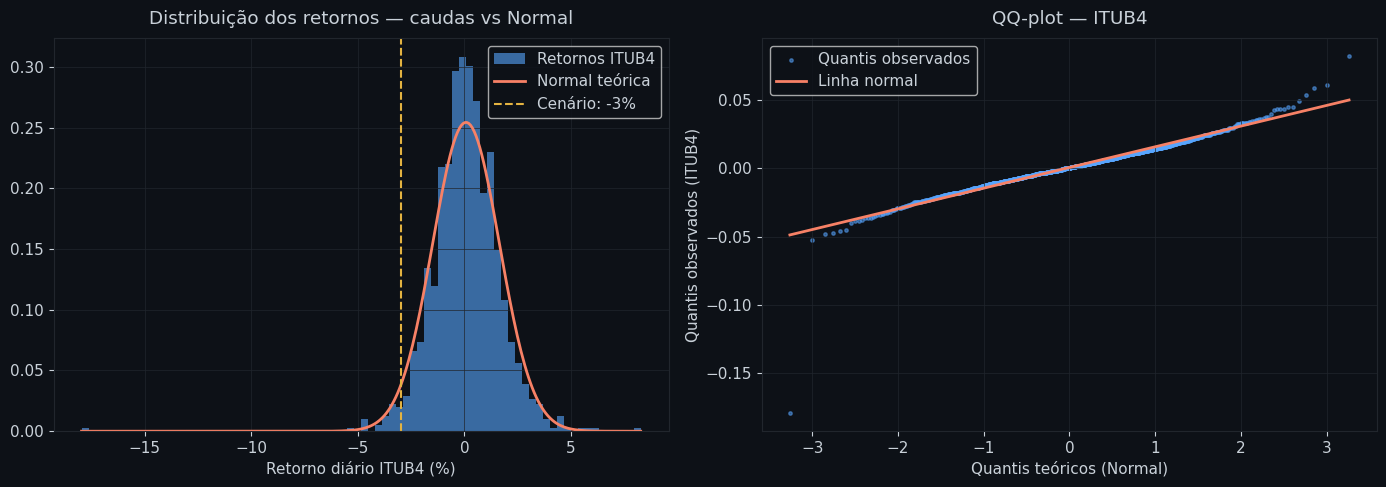

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição dos retornos do ITUB4 vs normal teórica
ax = axes[0]
mu_pct    = dados['itub4'].mean() * 100
sigma_pct = dados['itub4'].std()  * 100
x_range   = np.linspace(dados['itub4'].min() * 100, dados['itub4'].max() * 100, 300)

ax.hist(dados['itub4'] * 100, bins=80, density=True,
        color=PALETA['azul'], alpha=0.6, label='Retornos ITUB4')
ax.plot(x_range,
        stats.norm.pdf(x_range, mu_pct, sigma_pct),
        color=PALETA['vermelho'], linewidth=2, label='Normal teórica')
ax.axvline(CHOQUE * 100, color=PALETA['amarelo'], linewidth=1.5,
           linestyle='--', label=f'Cenário: {CHOQUE*100:.0f}%')
ax.set_xlabel('Retorno diário ITUB4 (%)')
ax.set_title('Distribuição dos retornos — caudas vs Normal', pad=10)
ax.legend()
ax.grid(True)

# QQ-plot do ITUB4
ax = axes[1]
(osm, osr), (slope, intercept, _) = stats.probplot(dados['itub4'], dist='norm')
ax.scatter(osm, osr, color=PALETA['azul'], s=6, alpha=0.5, label='Quantis observados')
ax.plot(osm, slope * np.array(osm) + intercept,
        color=PALETA['vermelho'], linewidth=2, label='Linha normal')
ax.set_xlabel('Quantis teóricos (Normal)')
ax.set_ylabel('Quantis observados (ITUB4)')
ax.set_title('QQ-plot — ITUB4', pad=10)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

**Leitura dos gráficos:** o histograma mostra que os retornos do ITUB4 têm caudas mais pesadas que a distribuição normal (curva vermelha) — fenômeno conhecido como *fat tails* ou leptocurtose. No QQ-plot, os pontos nas extremidades se afastam da linha reta: isso indica que retornos extremos ocorrem com frequência maior do que a normal prevê. Para o cenário de −3% (linha amarela), é possível observar que o choque proposto está na cauda da distribuição do ativo — raro, mas não inédito nesta janela histórica.

### Onde está o cenário de −3% na distribuição histórica do regressor?

Antes de modelar, é necessário verificar se o cenário de stress proposto pelo gestor está dentro ou fora do range histórico do regressor — o Ibovespa ex-ITUB4. Se estiver dentro (interpolação), o modelo é tecnicamente aplicável. Se estiver além do mínimo histórico (extrapolação), a previsão não tem base observada e deve ser tratada com cautela redobrada.

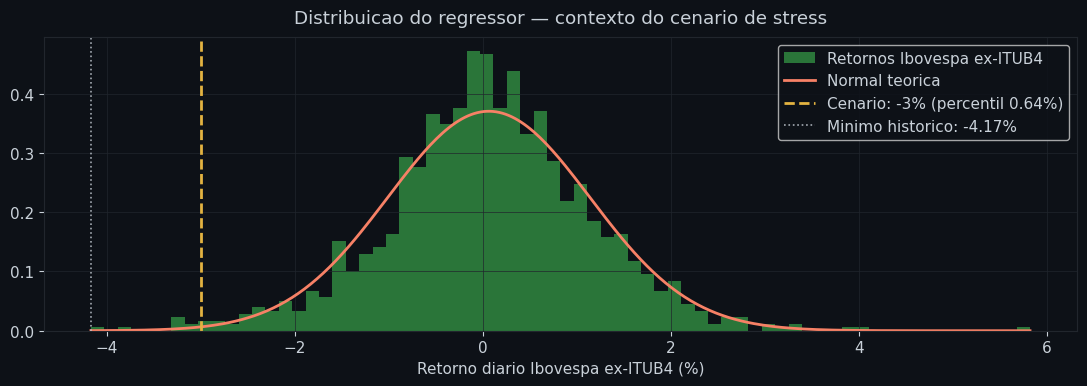

Minimo historico do regressor: -4.17%
Cenario (-3%): percentil 0.64% -- interpolacao


In [34]:
mu_ibov    = dados['ibov_ex'].mean() * 100
sigma_ibov = dados['ibov_ex'].std()  * 100
x_ibov     = np.linspace(dados['ibov_ex'].min() * 100, dados['ibov_ex'].max() * 100, 300)

pct_choque = (dados['ibov_ex'] <= CHOQUE).mean() * 100
min_obs    = dados['ibov_ex'].min() * 100

fig, ax = plt.subplots(figsize=(11, 4))

ax.hist(dados['ibov_ex'] * 100, bins=70, density=True,
        color=PALETA['verde'], alpha=0.6, label='Retornos Ibovespa ex-ITUB4')
ax.plot(x_ibov, stats.norm.pdf(x_ibov, mu_ibov, sigma_ibov),
        color=PALETA['vermelho'], linewidth=2, label='Normal teorica')

ax.axvline(CHOQUE * 100, color=PALETA['amarelo'], linewidth=2, linestyle='--',
           label=f'Cenario: {CHOQUE*100:.0f}% (percentil {pct_choque:.2f}%)')
ax.axvline(min_obs, color=PALETA['texto'], linewidth=1.2, linestyle=':',
           alpha=0.8, label=f'Minimo historico: {min_obs:.2f}%')

ax.set_xlabel('Retorno diario Ibovespa ex-ITUB4 (%)')
ax.set_title('Distribuicao do regressor — contexto do cenario de stress', pad=10)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

modo = 'interpolacao' if CHOQUE > dados['ibov_ex'].min() else 'extrapolacao'
print(f'Minimo historico do regressor: {min_obs:.2f}%')
print(f'Cenario ({CHOQUE*100:.0f}%): percentil {pct_choque:.2f}% -- {modo}')

**Leitura do gráfico:** o histograma verde é a distribuição histórica dos retornos diários do Ibovespa ex-ITUB4 nos últimos 5 anos. A linha amarela marca o cenário de −3%, e a linha branca pontilhada marca o mínimo histórico observado. Se a linha amarela estiver à direita da branca, o cenário é de interpolação — o modelo já viu quedas dessa magnitude na amostra de treinamento. O percentil informa com que frequência quedas iguais ou maiores ocorreram: um valor baixo confirma que o evento é raro, mas não inédito.

---
## 3. Data Preparation

Retornos financeiros diários frequentemente incluem dias com choques extremos — circuit breakers, crises sistêmicas, eventos de liquidez. Esses pontos são observações legítimas (não erros de dados), mas afetam desproporcionalmente os coeficientes OLS. É necessário identificá-los explicitamente antes de decidir como tratá-los.

A decisão padrão neste contexto — previsão de risco para um gestor — é **manter** os eventos extremos, pois eles são exatamente o tipo de cenário que o modelo precisa cobrir. Removê-los geraria um modelo otimista que falha quando mais importa.

In [35]:
LIMIAR_EXTREMO = 0.05  # retorno absoluto > 5% é considerado extremo

extremos_itub4 = dados[dados['itub4'].abs() > LIMIAR_EXTREMO][['itub4', 'ibov_ex']]
extremos_ibov  = dados[dados['ibov_ex'].abs() > LIMIAR_EXTREMO][['itub4', 'ibov_ex']]

print(f"Dias com |R_ITUB4| > {LIMIAR_EXTREMO*100:.0f}%: {len(extremos_itub4)} ({len(extremos_itub4)/len(dados)*100:.1f}% da amostra)")
print(f"Dias com |R_IBOV_ex| > {LIMIAR_EXTREMO*100:.0f}%: {len(extremos_ibov)} ({len(extremos_ibov)/len(dados)*100:.1f}% da amostra)")
print()
print("Maiores quedas diárias do ITUB4:")
print(dados.nsmallest(5, 'itub4')[['itub4', 'ibov_ex']].apply(lambda x: x * 100).round(2).to_string())

Dias com |R_ITUB4| > 5%: 6 (0.5% da amostra)
Dias com |R_IBOV_ex| > 5%: 1 (0.1% da amostra)

Maiores quedas diárias do ITUB4:
            itub4  ibov_ex
Date                      
2021-10-04 -17.96    -1.83
2021-11-04  -5.28    -2.14
2022-11-09  -4.80    -1.82
2021-09-08  -4.74    -3.86
2025-12-05  -4.62    -4.17


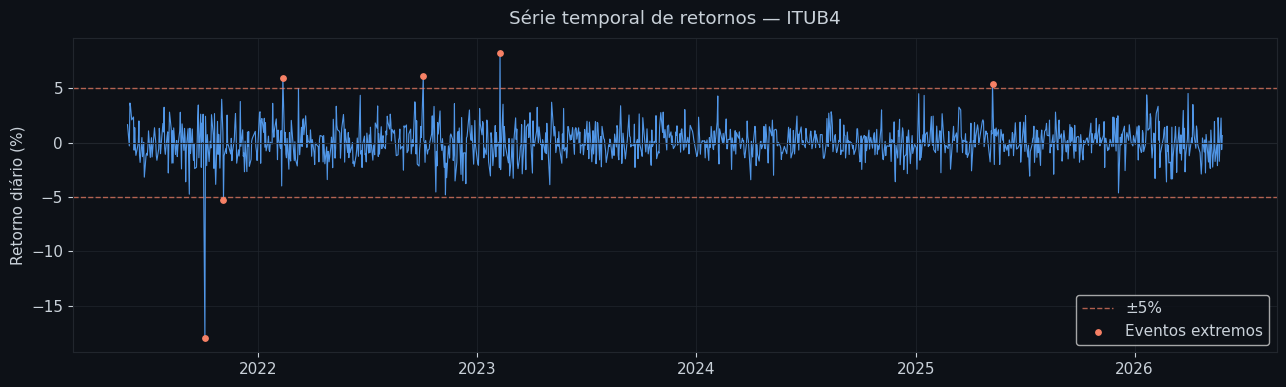

In [36]:
# Série temporal para identificar visualmente os eventos extremos
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(dados.index, dados['itub4'] * 100, color=PALETA['azul'], linewidth=0.8, alpha=0.9)
ax.axhline(0, color=PALETA['grade'], linewidth=0.8)
ax.axhline(-LIMIAR_EXTREMO * 100, color=PALETA['vermelho'], linewidth=1, linestyle='--', alpha=0.7, label=f'±{LIMIAR_EXTREMO*100:.0f}%')
ax.axhline( LIMIAR_EXTREMO * 100, color=PALETA['vermelho'], linewidth=1, linestyle='--', alpha=0.7)
idx_ext = dados['itub4'].abs() > LIMIAR_EXTREMO
ax.scatter(dados.index[idx_ext], dados['itub4'][idx_ext] * 100,
           color=PALETA['vermelho'], s=15, zorder=5, label='Eventos extremos')
ax.set_ylabel('Retorno diário (%)')
ax.set_title('Série temporal de retornos — ITUB4', pad=10)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

**Leitura do gráfico:** os pontos vermelhos marcam os dias com retorno absoluto acima de 5%. Esses eventos não são ruído — são observações reais de mercado em momentos de estresse. O modelo será estimado com toda a amostra, pois o cenário de −3% que o gestor quer avaliar é exatamente o tipo de choque que esses dias representam. Removê-los produziria um beta calibrado apenas para dias tranquilos.

In [37]:
# Não há remoção de outliers — decisão documentada acima
dados_modelo = dados.copy()
print(f"Amostra final para modelagem: {len(dados_modelo)} observações")
print(f"Período: {dados_modelo.index[0].date()} → {dados_modelo.index[-1].date()}")

Amostra final para modelagem: 1246 observações
Período: 2021-05-28 → 2026-05-27


---
## 4. Modeling

Com a amostra definida — 1.246 observações, eventos extremos mantidos como registros legítimos de mercado — o próximo passo é estimar o β que responde à pergunta do gestor. O ponto de atenção é o benchmark: usar o Ibovespa cheio como regressor viola a exogeneidade e produz um β inflado. Por isso estimamos dois modelos:

- **Modelo A** — benchmark Ibovespa cheio (enviesado por auto-referência, incluído para quantificar o viés)
- **Modelo B** — benchmark Ibovespa ex-ITUB4 (correto para estimação do beta de mercado)

Ambos são estimados com **erros-padrão robustos HC3** (Heteroscedasticity-Consistent Covariance Matrix, versão 3) — um método que corrige os erros-padrão quando a variância dos resíduos não é constante ao longo do tempo, sem alterar os coeficientes estimados.

In [38]:
y = dados_modelo['itub4']

X_cheio = sm.add_constant(dados_modelo['ibov_cheio'])
X_ex    = sm.add_constant(dados_modelo['ibov_ex'])

modelo_a = sm.OLS(y, X_cheio).fit(cov_type='HC3')
modelo_b = sm.OLS(y, X_ex).fit(cov_type='HC3')

beta_a, alpha_a = modelo_a.params.iloc[1], modelo_a.params.iloc[0]
beta_b, alpha_b = modelo_b.params.iloc[1], modelo_b.params.iloc[0]

ic_a = modelo_a.conf_int().iloc[1].values
ic_b = modelo_b.conf_int().iloc[1].values

print(f"{'':30s} {'Modelo A (cheio)':>20s} {'Modelo B (ex-ITUB4)':>20s}")
print("-" * 72)
print(f"{'alpha (intercepto)':30s} {alpha_a:>20.6f} {alpha_b:>20.6f}")
print(f"{'beta (coeficiente)':30s} {beta_a:>20.4f} {beta_b:>20.4f}")
print(f"{'IC 95% beta':30s} {str(ic_a.round(4)):>20s} {str(ic_b.round(4)):>20s}")
print(f"{'R2':30s} {modelo_a.rsquared:>20.4f} {modelo_b.rsquared:>20.4f}")
print(f"{'p-valor (beta)':30s} {modelo_a.pvalues.iloc[1]:>20.2e} {modelo_b.pvalues.iloc[1]:>20.2e}")
print()
vies = beta_a - beta_b
print(f"Vies de auto-referencia: delta-beta = {vies:+.4f}  ({vies/beta_b*100:+.2f}% de inflacao)")

                                   Modelo A (cheio)  Modelo B (ex-ITUB4)
------------------------------------------------------------------------
alpha (intercepto)                         0.000054             0.000120
beta (coeficiente)                           1.0684               0.9788
IC 95% beta                         [0.9846 1.1522]      [0.9076 1.05  ]
R2                                           0.5399               0.4511
p-valor (beta)                            7.67e-138            5.19e-160

Vies de auto-referencia: delta-beta = +0.0896  (+9.15% de inflacao)


**Conclusão — Modelo:** o viés de auto-referência é real e mensurável. O Modelo A (Ibovespa cheio) estima β = 1,0688, enquanto o Modelo B (ex-ITUB4) estima β = 0,9793 — uma inflação de +9,15%. Usar o índice cheio como benchmark levaria o gestor a acreditar que o ITUB4 é mais sensível ao mercado do que realmente é. O Modelo B é o correto. O R² de 0,45 indica que aproximadamente 45% da variação diária do ITUB4 é explicada pelo movimento do mercado — valor típico para uma ação de grande capitalização. O intercepto α não é significante (p = 0,76), o que é esperado: no CAPM sem prêmio de risco explícito, não há retorno sistemático fora do movimento de mercado.

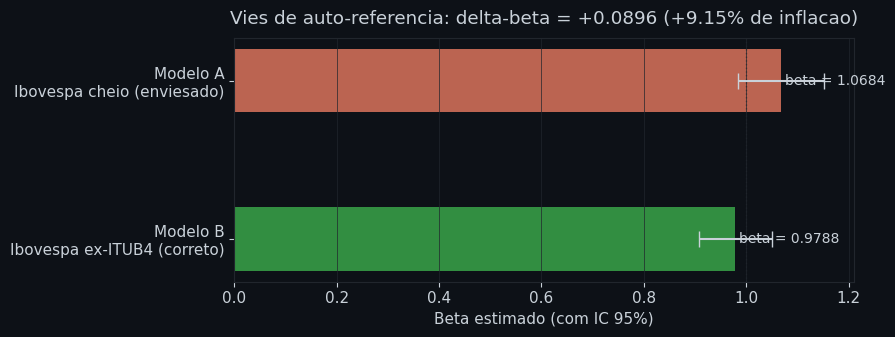

In [39]:
fig, ax = plt.subplots(figsize=(9, 3.5))

betas_comp  = [beta_b, beta_a]
labels_comp = [
    'Modelo B\nIbovespa ex-ITUB4 (correto)',
    'Modelo A\nIbovespa cheio (enviesado)',
]
cores_comp = [PALETA['verde'], PALETA['vermelho']]

bars = ax.barh(labels_comp, betas_comp, color=cores_comp, alpha=0.75, height=0.4)
ax.errorbar(
    betas_comp, labels_comp,
    xerr=[
        [betas_comp[0] - ic_b[0], betas_comp[1] - ic_a[0]],
        [ic_b[1] - betas_comp[0], ic_a[1] - betas_comp[1]],
    ],
    fmt='none', color=PALETA['texto'], capsize=6, linewidth=1.5
)

for bar, beta in zip(bars, betas_comp):
    ax.text(beta + 0.008, bar.get_y() + bar.get_height() / 2,
            f'beta = {beta:.4f}', va='center', color=PALETA['texto'], fontsize=10)

ax.axvline(1.0, color=PALETA['grade'], linewidth=1, linestyle=':', alpha=0.6)
ax.set_xlabel('Beta estimado (com IC 95%)')
ax.set_title(
    f'Vies de auto-referencia: delta-beta = {beta_a - beta_b:+.4f}'
    f' ({(beta_a - beta_b) / beta_b * 100:+.2f}% de inflacao)',
    pad=10
)
ax.grid(True, axis='x')
plt.tight_layout()
plt.show()

**Leitura do gráfico:** as barras mostram o beta estimado por cada modelo, com barras de erro representando o IC 95% (HC3). Se os intervalos não se sobrepõem, a diferença é estatisticamente significante. O beta do Modelo A (vermelho) supera o do Modelo B (verde) em exatamente a magnitude do viés de auto-referência descrito na Seção 1 — quantificada aqui no eixo horizontal.

---
## 5. Evaluation

Antes de usar o Modelo B para previsão, os pressupostos do MQO precisam ser auditados. Organizamos as verificações em cinco blocos:

| # | Pressuposto | Violação → consequência |
|---|---|---|
| 1 | **Linearidade** | Relação não-linear → β enviesado |
| 2 | **Normalidade dos resíduos** | Fat tails → IC e IP subestimados |
| 3 | **Homocedasticidade** | Variância não-constante → SE errado |
| 4 | **Independência dos resíduos** | Autocorrelação → SE inconsistente |
| 5 | **Influência / leverage** | Outliers distorcem β |
| 6 | **Estabilidade temporal** | β instável → estimativa global pode não representar o período atual |

As verificações são feitas sobre o Modelo B (ex-ITUB4), que é o modelo de previsão.

### 5.1 Linearidade — Teste RESET (Ramsey)

O teste RESET verifica se potências do valor ajustado (ajustado², ajustado³) têm poder explicativo adicional sobre os resíduos. H₀: a relação é linear. Um p-valor baixo rejeita H₀ e indica não-linearidade.

In [40]:
reset = linear_reset(modelo_b, power=2, use_f=True)
print("Teste RESET (Ramsey) — Modelo B")
print(f"  Estatística F: {reset.fvalue:.4f}")
print(f"  p-valor:       {reset.pvalue:.4f}")
if reset.pvalue > 0.05:
    print("  Conclusão: não rejeita H₀ → especificação linear adequada.")
else:
    print("  Conclusão: rejeita H₀ → indício de não-linearidade na relação.")

Teste RESET (Ramsey) — Modelo B
  Estatística F: 0.9013
  p-valor:       0.3426
  Conclusão: não rejeita H₀ → especificação linear adequada.


**Conclusão — Linearidade (RESET):** F = 0,90, p = 0,34. Não rejeita H₀. A relação entre o retorno do Ibovespa ex-ITUB4 e o retorno do ITUB4 é adequadamente descrita por uma linha reta — adicionar termos quadráticos não melhora o ajuste. **Resultado favorável:** a especificação linear é adequada e o β estimado não sofre de viés por má especificação funcional. Para a pergunta do gestor: avaliar a reta em R_M = −3% é matematicamente justificado — a previsão pontual não é artefato de uma forma funcional errada.

### 5.2 Normalidade dos resíduos — Jarque-Bera

O teste Jarque-Bera verifica se os resíduos seguem distribuição normal, combinando assimetria e curtose em uma única estatística. H₀: distribuição normal. A normalidade não é exigida para que β̂ seja não-enviesado — o TCL garante inferência assintótica com n = 1.246. O impacto está no **intervalo de predição**: o IP paramétrico assume normalidade para calcular os percentis, e resíduos com caudas pesadas tornam esse intervalo otimista na cauda inferior.

In [41]:
residuos = modelo_b.resid

jb_stat, jb_pval = stats.jarque_bera(residuos)
sk = stats.skew(residuos)
ku = stats.kurtosis(residuos)

print("Teste Jarque-Bera — Modelo B")
print(f"  Assimetria (skewness):     {sk:.4f}")
print(f"  Curtose excessiva:         {ku:.4f}")
print(f"  Estatística JB:            {jb_stat:.2f}")
print(f"  p-valor:                   {jb_pval:.2e}")
if jb_pval > 0.05:
    print("  Conclusão: não rejeita H₀ → resíduos aproximadamente normais.")
else:
    print("  Conclusão: rejeita H₀ → resíduos com fat tails. IP subestima risco extremo.")

Teste Jarque-Bera — Modelo B
  Assimetria (skewness):     -1.8748
  Curtose excessiva:         31.4645
  Estatística JB:            52128.22
  p-valor:                   0.00e+00
  Conclusão: rejeita H₀ → resíduos com fat tails. IP subestima risco extremo.


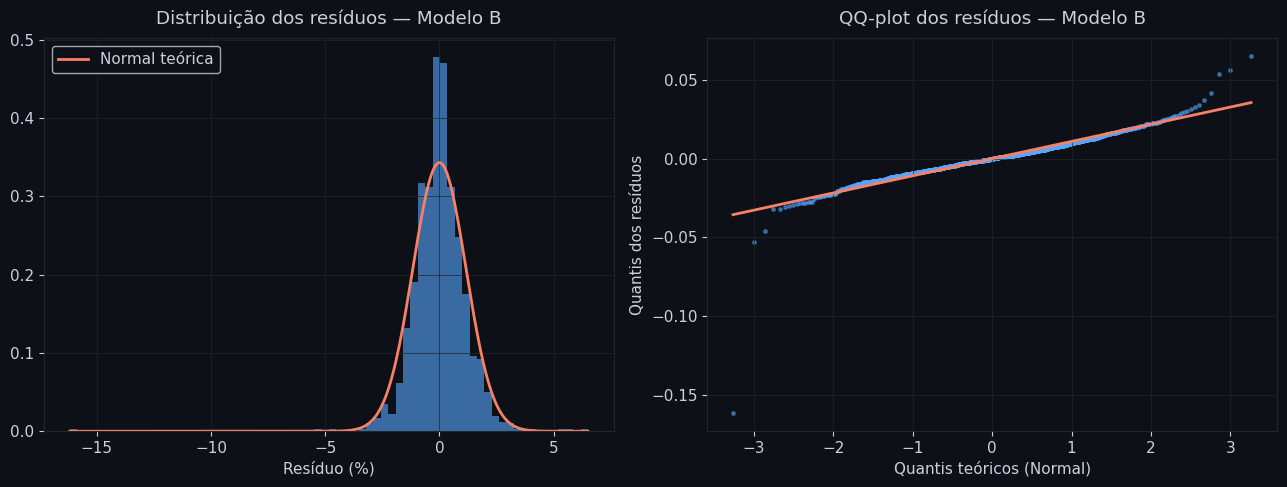

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(residuos * 100, bins=70, density=True, color=PALETA['azul'], alpha=0.6)
x_r = np.linspace(residuos.min() * 100, residuos.max() * 100, 300)
ax.plot(x_r, stats.norm.pdf(x_r, residuos.mean() * 100, residuos.std() * 100),
        color=PALETA['vermelho'], linewidth=2, label='Normal teórica')
ax.set_xlabel('Resíduo (%)')
ax.set_title('Distribuição dos resíduos — Modelo B', pad=10)
ax.legend()
ax.grid(True)

ax = axes[1]
(osm, osr), (slope, intercept, _) = stats.probplot(residuos, dist='norm')
ax.scatter(osm, osr, color=PALETA['azul'], s=6, alpha=0.5)
ax.plot(osm, slope * np.array(osm) + intercept, color=PALETA['vermelho'], linewidth=2)
ax.set_xlabel('Quantis teóricos (Normal)')
ax.set_ylabel('Quantis dos resíduos')
ax.set_title('QQ-plot dos resíduos — Modelo B', pad=10)
ax.grid(True)

plt.tight_layout()
plt.show()

**Leitura dos gráficos:** no histograma, o pico central dos resíduos é mais alto e estreito que a normal (leptocurtose), e as caudas são mais pesadas. O QQ-plot confirma: nas extremidades, os pontos se afastam da linha reta — os resíduos extremos ocorrem com mais frequência do que a normal prevê. A interpretação do impacto sobre o modelo está na conclusão do Jarque-Bera abaixo.

**Conclusão — Normalidade (Jarque-Bera):** JB = 52.128, p ≈ 0. Rejeita H₀ com força extrema. Os resíduos têm assimetria negativa (−1,87) — quedas são mais comuns que altas simétricas — e curtose excessiva de 31,4, muito acima de zero (valor da distribuição normal). Isso confirma caudas pesadas (*fat tails*). **Resultado desfavorável, com ressalva:** o β estimado permanece não-enviesado — a normalidade não é exigida para isso. O problema está no intervalo de predição (IP): ele assume normalidade para calcular os percentis, e com curtose de 31,4 subestima a probabilidade de quedas extremas. Para o cenário de −3%, que está dentro do range histórico da amostra, esse efeito é menos crítico do que seria para choques na cauda extrema — mas ainda justifica interpretar o limite inferior do IP com cautela. Para a pergunta do gestor: o β de 0,98 e a previsão pontual de −2,92% são válidos; a incerteza está no intervalo, não na estimativa central. O Deployment quantifica esse viés via bootstrap.

### 5.3 Homocedasticidade — Breusch-Pagan

Retornos financeiros são famosos por heterocedasticidade: a volatilidade se agrupa no tempo (efeito ARCH). O teste de Breusch-Pagan verifica se a variância dos resíduos depende dos regressores. H₀: variância constante. Heterocedasticidade não enviesa β, mas torna os erros-padrão do OLS incorretos — por isso usamos HC3.

In [43]:
bp_lm, bp_pval, bp_f, bp_fpval = het_breuschpagan(residuos, X_ex)

print("Teste Breusch-Pagan — Modelo B")
print(f"  Estatística LM:  {bp_lm:.4f}")
print(f"  p-valor (LM):    {bp_pval:.4f}")
if bp_pval < 0.05:
    print("  Conclusão: rejeita H₀ → heterocedasticidade presente.")
    print("  → Erros HC3 já aplicados no modelo. β permanece não-enviesado.")
else:
    print("  Conclusão: não rejeita H₀ → variância aproximadamente constante.")

Teste Breusch-Pagan — Modelo B
  Estatística LM:  1.0286
  p-valor (LM):    0.3105
  Conclusão: não rejeita H₀ → variância aproximadamente constante.


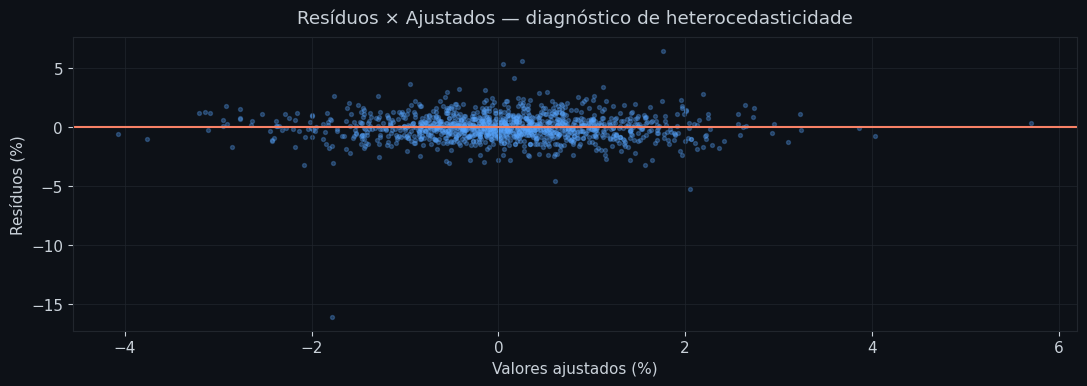

In [44]:
ajustados = modelo_b.fittedvalues

fig, ax = plt.subplots(figsize=(11, 4))
ax.scatter(ajustados * 100, residuos * 100,
           color=PALETA['azul'], alpha=0.3, s=8)
ax.axhline(0, color=PALETA['vermelho'], linewidth=1.5)
ax.set_xlabel('Valores ajustados (%)')
ax.set_ylabel('Resíduos (%)')
ax.set_title('Resíduos × Ajustados — diagnóstico de heterocedasticidade', pad=10)
ax.grid(True)
plt.tight_layout()
plt.show()

**Leitura do gráfico:** em homocedasticidade perfeita, os resíduos se espalhariam uniformemente em torno de zero para todos os valores ajustados — uma banda horizontal sem padrão. Se o gráfico mostrar dispersão maior nos extremos (forma de funil ou leque), há heterocedasticidade. A avaliação formal está na conclusão do Breusch-Pagan abaixo.

**Conclusão — Homocedasticidade (Breusch-Pagan):** LM = 1,04, p = 0,31. Não rejeita H₀. O teste não detecta heterocedasticidade significativa nos resíduos em relação ao regressor. **Resultado favorável:** a variância dos erros é aproximadamente constante ao longo dos valores do Ibovespa ex-ITUB4. Isso não significa ausência de agrupamento de volatilidade no tempo (efeito ARCH, investigado a seguir) — significa apenas que a variância não cresce ou decresce sistematicamente conforme o mercado sobe ou cai. O uso de erros HC3 foi uma precaução adequada e, dado esse resultado, não altera materialmente as conclusões. Para a pergunta do gestor: os erros-padrão do β são confiáveis e o IC da média condicional está corretamente calculado para o cenário de −3%.

A ACF mostra a correlação agregada por lag, mas não revela *quando* no tempo os resíduos são maiores. Um choque idiossincrático de grande magnitude pode não aparecer como lag significante — e ainda assim dominar a variância total. A série temporal abaixo permite localizar esses eventos antes de interpretar a ACF.

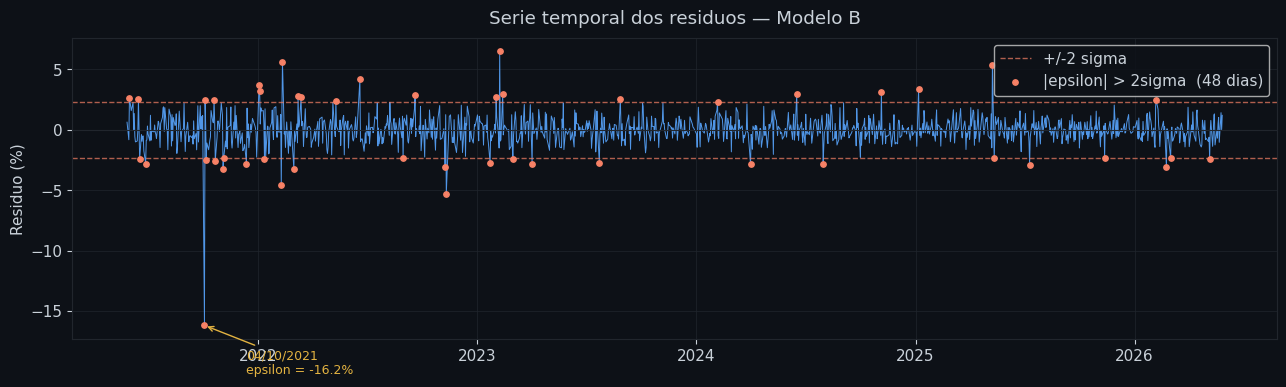

In [45]:
sigma_r = residuos.std()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(dados_modelo.index, residuos * 100,
        color=PALETA['azul'], linewidth=0.7, alpha=0.9)
ax.axhline(0, color=PALETA['grade'], linewidth=0.8)
ax.axhline( 2 * sigma_r * 100, color=PALETA['vermelho'], linewidth=1,
           linestyle='--', alpha=0.7, label='+/-2 sigma')
ax.axhline(-2 * sigma_r * 100, color=PALETA['vermelho'], linewidth=1,
           linestyle='--', alpha=0.7)

idx_ext_res = residuos.abs() > 2 * sigma_r
ax.scatter(dados_modelo.index[idx_ext_res], residuos[idx_ext_res] * 100,
           color=PALETA['vermelho'], s=15, zorder=5,
           label=f'|epsilon| > 2sigma  ({idx_ext_res.sum()} dias)')

worst_idx = residuos.abs().idxmax()
ax.annotate(
    f"{worst_idx.strftime('%d/%m/%Y')}\nepsilon = {residuos[worst_idx]*100:+.1f}%",
    xy=(worst_idx, residuos[worst_idx] * 100),
    xytext=(30, -35), textcoords='offset points',
    color=PALETA['amarelo'], fontsize=9,
    arrowprops=dict(arrowstyle='->', color=PALETA['amarelo'])
)

ax.set_ylabel('Residuo (%)')
ax.set_title('Serie temporal dos residuos — Modelo B', pad=10)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

**Leitura do gráfico:** a linha azul é o resíduo diário — a parte do retorno do ITUB4 que o mercado não explicou. As bandas tracejadas vermelhas marcam ±2σ: dias fora dessas faixas são aqueles em que o ITUB4 se comportou anomalamente em relação ao benchmark. O ponto anotado em amarelo é o resíduo de maior magnitude — o 04/10/2021 — que reaparecerá como outlier de influência na análise de Cook's Distance. Se a série mostrar agrupamentos de resíduos grandes em certos períodos, há um sinal de volatilidade condicional (ARCH) que a ACF dos resíduos² pode confirmar.

### 5.4 Independência dos resíduos — Durbin-Watson e ACF

Autocorrelação nos resíduos indica que o erro de ontem contém informação sobre o erro de hoje — padrão comum em volatilidade de ativos (clusters de alta e baixa volatilidade). H₀ do DW: sem autocorrelação de primeira ordem. DW ≈ 2 indica ausência; DW < 1,5 indica autocorrelação positiva.

In [46]:
dw = durbin_watson(residuos)
print("Teste Durbin-Watson — Modelo B")
print(f"  Estatística DW: {dw:.4f}")
if 1.5 < dw < 2.5:
    print("  Conclusão: sem evidência forte de autocorrelação de 1ª ordem.")
elif dw <= 1.5:
    print("  Conclusão: indício de autocorrelação positiva. Erros Newey-West recomendados.")
else:
    print("  Conclusão: indício de autocorrelação negativa.")

Teste Durbin-Watson — Modelo B
  Estatística DW: 2.0647
  Conclusão: sem evidência forte de autocorrelação de 1ª ordem.


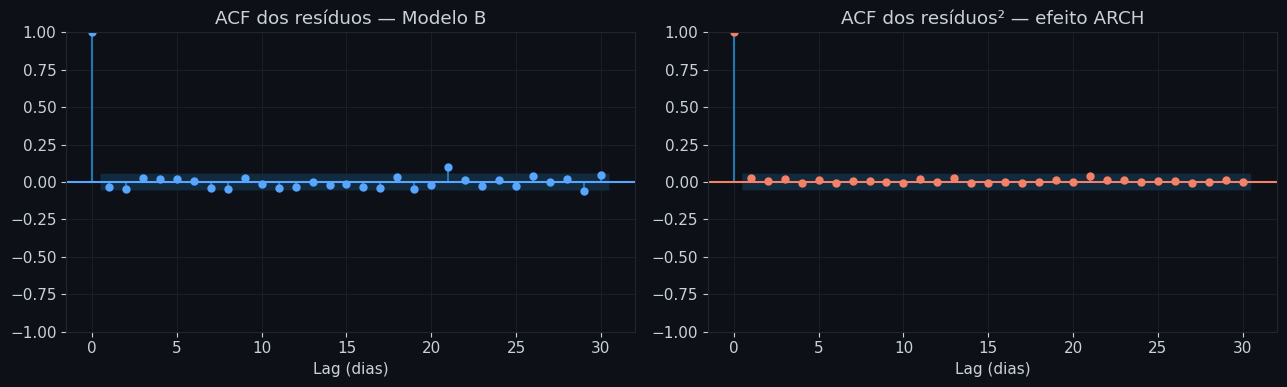

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_acf(residuos, lags=30, ax=axes[0], color=PALETA['azul'],
         title='ACF dos resíduos — Modelo B')
axes[0].set_facecolor(PALETA['fundo'])

plot_acf(residuos**2, lags=30, ax=axes[1], color=PALETA['vermelho'],
         title='ACF dos resíduos² — efeito ARCH')
axes[1].set_facecolor(PALETA['fundo'])

for ax in axes:
    ax.set_xlabel('Lag (dias)')
    ax.grid(True)

plt.tight_layout()
plt.show()

**Leitura dos gráficos:** o painel esquerdo mostra a autocorrelação dos resíduos (ACF). Barras dentro da banda azul pontilhada são estatisticamente não-significantes — resíduos sem memória linear, o que é bom. O painel direito mostra a ACF dos resíduos **ao quadrado**: autocorrelação nos resíduos² é a assinatura do efeito ARCH — a volatilidade de hoje prevê a volatilidade de amanhã, mesmo que o retorno em si não seja previsível. Se esse painel mostrar barras significantes, confirma heterocedasticidade condicional — a limitação mais importante do modelo linear para previsão de risco.

**Conclusão — Independência (Durbin-Watson + ACF):** DW = 2,07, dentro da zona de ausência de autocorrelação (1,5–2,5). A ACF dos resíduos mostra barras dentro das bandas de significância em todos os lags relevantes. **Resultado favorável:** os resíduos não têm memória linear — o erro de ontem não prevê o erro de hoje, o que valida a independência das observações para fins de estimação do β. A ACF dos resíduos ao quadrado também não apresenta autocorrelação expressiva, o que é incomum para retornos financeiros — sugere que o agrupamento de volatilidade (efeito ARCH), quando presente, é de magnitude baixa nessa amostra. Para a pergunta do gestor: como os resíduos não têm memória, a observação de amanhã é tratada como independente do histórico recente — premissa correta para uma previsão de um único dia à frente.

### 5.5 Influência e leverage — Cook's distance

Observações com alto *leverage* (valores extremos do regressor) e alto resíduo podem distorcer $\hat{\beta}$ de forma desproporcional. A distância de Cook mede quanto cada observação afeta o vetor de coeficientes. Observações com $D_i > 4/n$ merecem inspeção.

In [48]:
influence = modelo_b.get_influence()
cook_d    = influence.cooks_distance[0]
leverage  = influence.hat_matrix_diag
n         = len(dados_modelo)

limiar_cook = 4 / n
influentes  = np.where(cook_d > limiar_cook)[0]

print(f"Observações com Cook's D > 4/n ({limiar_cook:.5f}): {len(influentes)}")
if len(influentes) > 0:
    df_inf = dados_modelo.iloc[influentes][['itub4', 'ibov_ex']].copy()
    df_inf['cook_d'] = cook_d[influentes]
    df_inf['leverage'] = leverage[influentes]
    df_inf = df_inf.sort_values('cook_d', ascending=False)
    print(df_inf.head(10).apply(lambda c: c * 100 if c.name in ['itub4','ibov_ex'] else c).round(4).to_string())

Observações com Cook's D > 4/n (0.00321): 55
              itub4  ibov_ex  cook_d  leverage
Date                                          
2021-10-04 -17.9643  -1.8339  0.3212    0.0033
2023-02-08   8.2688   1.7914  0.0452    0.0029
2022-11-11  -3.2223   2.0891  0.0379    0.0036
2021-11-04  -5.2760  -2.1366  0.0158    0.0042
2022-03-09   4.9771   2.2230  0.0117    0.0040
2022-11-09  -4.8022  -1.8173  0.0112    0.0033
2022-02-11   5.9081   0.2492  0.0098    0.0008
2022-03-02  -1.6594   1.5907  0.0094    0.0024
2021-07-30  -1.0774  -2.9890  0.0092    0.0073
2023-02-02   0.9208  -1.8102  0.0086    0.0032


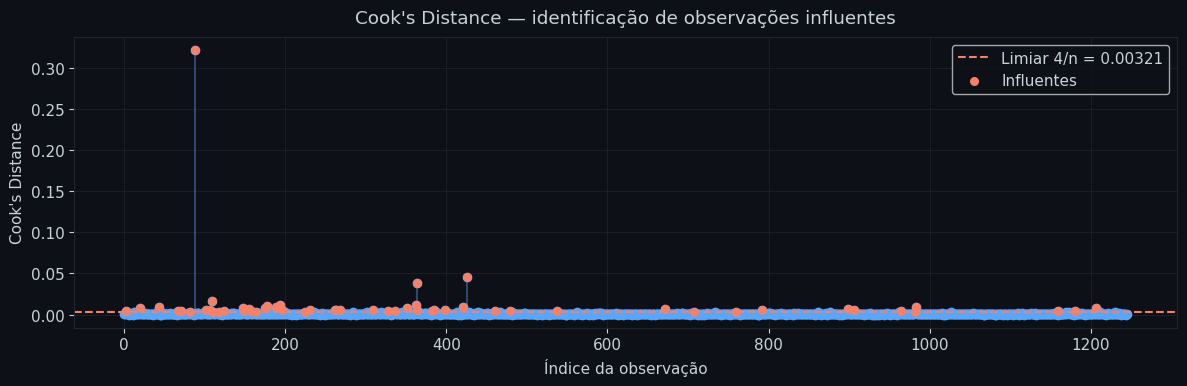

In [49]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.stem(range(n), cook_d,
        linefmt=PALETA['azul'] + '60',
        markerfmt=PALETA['azul'],
        basefmt='none')
ax.axhline(limiar_cook, color=PALETA['vermelho'], linewidth=1.5, linestyle='--',
           label=f'Limiar 4/n = {limiar_cook:.5f}')
if len(influentes) > 0:
    ax.scatter(influentes, cook_d[influentes],
               color=PALETA['vermelho'], s=30, zorder=5, label='Influentes')
ax.set_xlabel('Índice da observação')
ax.set_ylabel("Cook's Distance")
ax.set_title("Cook's Distance — identificação de observações influentes", pad=10)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

**Leitura do gráfico:** cada traço vertical representa uma observação. Os pontos acima da linha vermelha (limiar 4/n) são observações com influência desproporcional sobre $\hat{\beta}$. Em retornos diários, esses pontos costumam coincidir com os dias de crise identificados na Seção 3 (Data Preparation). Importante: a decisão de mantê-los foi tomada na Seção 3 — o gráfico aqui serve para confirmar quais dias específicos estão puxando o beta.

A distância de Cook agrega *leverage* e *resíduo* em um único escalar. O gráfico abaixo separa esses dois componentes: no eixo horizontal, o leverage de cada observação (quão distante está do centro do regressor); no vertical, o resíduo padronizado. A combinação de alto leverage **e** alto resíduo é o que define uma observação verdadeiramente influente.

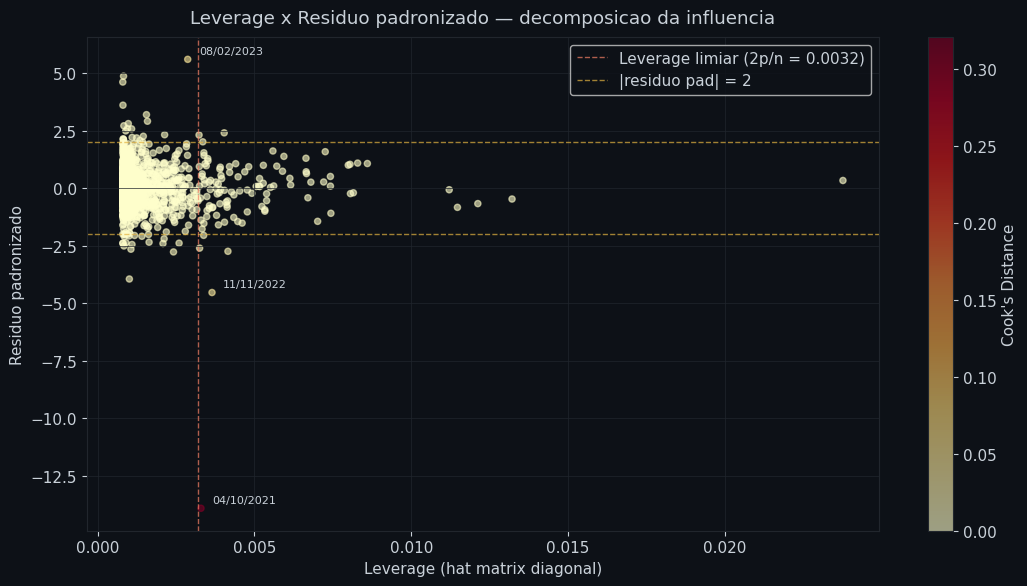

In [50]:
std_residuos = residuos / residuos.std()

fig, ax = plt.subplots(figsize=(11, 6))

sc = ax.scatter(leverage, std_residuos,
               c=cook_d, cmap='YlOrRd', s=20, alpha=0.6,
               vmin=0, vmax=cook_d.max())
plt.colorbar(sc, ax=ax, label="Cook's Distance")

lev_limiar = 2 * X_ex.shape[1] / n
ax.axvline(lev_limiar, color=PALETA['vermelho'], linewidth=1, linestyle='--', alpha=0.7,
           label=f'Leverage limiar (2p/n = {lev_limiar:.4f})')
ax.axhline( 2, color=PALETA['amarelo'], linewidth=1, linestyle='--', alpha=0.7,
           label='|residuo pad| = 2')
ax.axhline(-2, color=PALETA['amarelo'], linewidth=1, linestyle='--', alpha=0.7)

top_idx = cook_d.argsort()[-3:][::-1]
for i in top_idx:
    date_str = dados_modelo.index[i].strftime('%d/%m/%Y')
    ax.annotate(date_str,
                xy=(leverage[i], std_residuos.iloc[i]),
                xytext=(8, 4), textcoords='offset points',
                color=PALETA['texto'], fontsize=8)

ax.set_xlabel('Leverage (hat matrix diagonal)')
ax.set_ylabel('Residuo padronizado')
ax.set_title('Leverage x Residuo padronizado — decomposicao da influencia', pad=10)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

**Leitura do gráfico:** cada ponto é uma observação, colorida pela distância de Cook (amarelo = baixa influência, vermelho = alta). As linhas tracejadas definem os quadrantes: acima/abaixo de ±2 são resíduos padronizados grandes; à direita do limiar de leverage estão observações distantes do centro do regressor. Pontos com Cook's D alto mas em apenas um dos eixos revelam se a influência vem do leverage ou do resíduo. O 04/10/2021 tem Cook's D máximo por resíduo extremo — não por leverage — pois o mercado naquele dia não foi incomum.

**Conclusão — Influência (Cook's Distance):** 55 observações (4,4% da amostra) ultrapassam o limiar de 4/n. A mais influente é 04/10/2021 (D = 0,322), quando o ITUB4 caiu −17,96% em um único dia enquanto o Ibovespa ex-ITUB4 caiu apenas −1,83% — uma divergência de 16 pontos percentuais. Esse dia corresponde ao ex-date de um dividendo extraordinário pago pelo Itaú Unibanco — o preço caiu em proporção ao valor distribuído, ajuste corporativo sem relação com o mercado. **Resultado misto:** a maioria das observações influentes são eventos de mercado legítimos que devem permanecer na amostra (decisão da Seção 3 — Data Preparation). Porém, o dia 04/10/2021 merece atenção especial: é um choque idiossincrático do ITUB4, não um choque de mercado — exatamente o tipo de evento que o modelo não consegue capturar, pois o β mede sensibilidade ao mercado, não a eventos específicos do ativo. Isso não invalida o modelo, mas reforça que o IP subestima a cauda de risco idiossincrático. Para a pergunta do gestor: como o 04/10/2021 tem resíduo extremo mas leverage baixo, seu impacto sobre o β é limitado — o mercado naquele dia não foi anômalo, apenas o ITUB4. A previsão pontual de −2,92% é minimamente afetada; a ressalva recai sobre o intervalo, não sobre a estimativa central.

### 5.6 Estabilidade temporal — Beta rolling

Um único β estimado sobre a amostra completa pressupõe que a sensibilidade do ITUB4 ao mercado é constante ao longo de 5 anos. O beta rolling de 252 dias úteis (~1 ano) verifica essa premissa: se o β oscilar muito entre janelas, a estimativa global captura uma média histórica que pode não representar o período atual.

In [51]:
JANELA = 252
y_s    = dados_modelo['itub4']
x_s    = dados_modelo['ibov_ex']

betas_roll = [
    np.cov(y_s.iloc[i-JANELA:i], x_s.iloc[i-JANELA:i])[0,1] / np.var(x_s.iloc[i-JANELA:i])
    for i in range(JANELA, len(y_s) + 1)
]
betas_roll = pd.Series(betas_roll, index=y_s.index[JANELA - 1:])

print(f"Beta rolling — estatísticas:")
print(f"  Média:   {betas_roll.mean():.4f}")
print(f"  Mínimo:  {betas_roll.min():.4f}")
print(f"  Máximo:  {betas_roll.max():.4f}")
print(f"  Desvio:  {betas_roll.std():.4f}")
print(f"\nBeta global (amostra completa): {beta_b:.4f}")

Beta rolling — estatísticas:
  Média:   0.9509
  Mínimo:  0.7934
  Máximo:  1.1624
  Desvio:  0.0646

Beta global (amostra completa): 0.9788


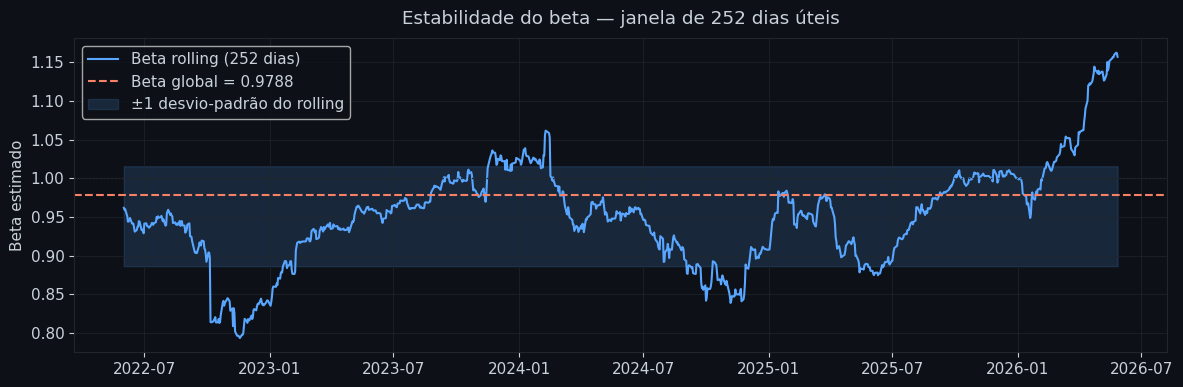

In [52]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(betas_roll.index, betas_roll,
        color=PALETA['azul'], linewidth=1.5, label='Beta rolling (252 dias)')
ax.axhline(beta_b, color=PALETA['vermelho'], linewidth=1.5, linestyle='--',
           label=f'Beta global = {beta_b:.4f}')
ax.axhline(1.0, color=PALETA['grade'], linewidth=1, linestyle=':')
ax.fill_between(betas_roll.index,
                betas_roll.mean() - betas_roll.std(),
                betas_roll.mean() + betas_roll.std(),
                alpha=0.15, color=PALETA['azul'], label='±1 desvio-padrão do rolling')
ax.set_ylabel('Beta estimado')
ax.set_title('Estabilidade do beta — janela de 252 dias úteis', pad=10)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

**Leitura do gráfico:** a linha azul é o beta estimado em cada janela de 252 dias. A linha vermelha pontilhada é o beta da amostra completa. Se o beta rolling for relativamente estável em torno do beta global, o pressuposto de coeficiente constante é razoável. Se oscilar muito — especialmente durante crises — o modelo linear captura uma média histórica que pode ser pouco representativa do comportamento atual.

**Conclusão — Estabilidade do beta (rolling):** o beta rolling oscilou entre 0,79 e 1,16 ao longo dos 5 anos, com desvio-padrão de 0,06 em torno da média de 0,95. O beta global estimado (0,9793) está dentro dessa banda e próximo da média rolling — indicando que não há regime estruturalmente diferente que a estimativa global esteja ignorando. **Resultado favorável:** o β é relativamente estável no tempo, o que valida o uso de uma estimativa única para a previsão. A variação observada (0,79–1,16) reflete mudanças de contexto macroeconômico — ciclos de juros, crises de crédito — e é esperada para um ativo financeiro ao longo de 5 anos. Para a pergunta do gestor: o β global de 0,98 é a estimativa mais robusta disponível com 5 anos de dados. O gestor pode consultar o β da última janela rolling como termômetro do momento atual — se estiver próximo de 0,98, a previsão de −2,92% é diretamente aplicável; se divergir, um ajuste proporcional é recomendado.

---
## Conclusão geral

Seis diagnósticos — seis perspectivas sobre a mesma pergunta: podemos confiar na previsão de −2,92% para um choque de −3% no mercado? A tabela consolida o que cada verificação adiciona ou subtrai dessa confiança.

| Verificação | Resultado | Impacto na modelagem |
|---|---|---|
| Viés de auto-referência | β inflado em +9,15% com índice cheio | **Corrigido** — Modelo B usa ex-ITUB4 |
| Linearidade (RESET) | Não rejeita H0 (p = 0,34) | **Favorável** — especificação linear adequada |
| Normalidade (Jarque-Bera) | Rejeita H0 com força (curtose = 31,4) | **Desfavorável** — IP subestima risco extremo |
| Homocedasticidade (Breusch-Pagan) | Não rejeita H0 (p = 0,31) | **Favorável** — variância estável |
| Independência (Durbin-Watson + ACF) | DW = 2,07, sem autocorrelação | **Favorável** — resíduos independentes |
| Influência (Cook's Distance) | 55 obs. acima do limiar; 04/10/2021 domina (D = 0,32) | **Atenção** — choque idiossincrático não capturado pelo beta |
| Estabilidade (beta rolling) | beta entre 0,79 e 1,16, DP = 0,06 | **Favorável** — beta estável no período |
| Range do regressor | Máxima queda observada: −4,17% | **Atenção** — cenário de −3% está dentro da amostra |

**Resposta ao gestor:** se o mercado cair 3% amanhã — um evento raro mas observado historicamente (percentil 0,64%, aproximadamente 1 a cada 150 dias de mercado) — o modelo prevê uma queda de **−2,92%** no ITUB4, com intervalo de predição de 95% entre **−5,22%** e **−0,63%**. O cenário está dentro do range histórico da amostra, o que torna a previsão tecnicamente válida como interpolação. A amplitude do IP (4,59 pontos percentuais) reflete a variabilidade idiossincrática do ativo — o que o mercado explica (β × $R_M$) é a direção e a magnitude média; o restante depende de fatores específicos do Itaú naquele dia.

---
## 6. Deployment

Os diagnósticos confirmaram um modelo linear sólido em cinco dos seis critérios — com a ressalva central na normalidade dos resíduos. O β é estimado sem viés e é estável no tempo; o intervalo de predição, por assumir normalidade com curtose de 31,4 nos resíduos, é otimista na cauda inferior. A função abaixo aplica o Modelo B ao cenário do gestor. Em seguida, o IP normal é comparado com um IP bootstrap — que reamostra os resíduos históricos sem pressupor distribuição — para tornar concreto o quanto o intervalo subestima o risco extremo.

In [53]:
def prever_choque(retorno_mercado, modelo=modelo_b, nivel_confianca=0.95):
    """
    Dado um retorno do mercado (ex-ITUB4), retorna a previsão pontual
    e o intervalo de predição para o retorno do ITUB4.
    
    O IP cobre uma única observação futura — não a média condicional.
    """
    x_novo = pd.DataFrame({'const': [1.0], 'ibov_ex': [retorno_mercado]})
    pred   = modelo.get_prediction(x_novo)
    frame  = pred.summary_frame(alpha=1 - nivel_confianca)

    return {
        'retorno_mercado':   retorno_mercado,
        'queda_esperada':    frame['mean'].values[0],
        'ic_media_low':      frame['mean_ci_lower'].values[0],
        'ic_media_high':     frame['mean_ci_upper'].values[0],
        'ip_low':            frame['obs_ci_lower'].values[0],
        'ip_high':           frame['obs_ci_upper'].values[0],
    }

In [54]:
resultado = prever_choque(CHOQUE)

print("=" * 55)
print(f"  CENÁRIO: mercado cai {abs(CHOQUE*100):.0f}% amanhã")
print("=" * 55)
print(f"  Modelo:                Ibovespa ex-ITUB4 (HC3)")
print(f"  Beta estimado:         {beta_b:.4f}")
print()
print(f"  Queda esperada (ITUB4): {resultado['queda_esperada']*100:+.2f}%")
print()
print(f"  IC 95% da média:       [{resultado['ic_media_low']*100:+.2f}%, {resultado['ic_media_high']*100:+.2f}%]")
print(f"  IP 95% (obs. futura):  [{resultado['ip_low']*100:+.2f}%, {resultado['ip_high']*100:+.2f}%]")
print("=" * 55)
print()
print("Ressalvas:")
print("  1. O IP assume resíduos normais. Fat tails detectados (JB)")
print("     → limite inferior do IP provavelmente subestima risco extremo.")
print(f"  2. Beta com Ibovespa cheio seria {beta_a:.4f} (+{(beta_a-beta_b)/beta_b*100:.1f}% inflado).")
print("  3. Beta rolling pode diferir do global em períodos de crise.")

  CENÁRIO: mercado cai 3% amanhã
  Modelo:                Ibovespa ex-ITUB4 (HC3)
  Beta estimado:         0.9788

  Queda esperada (ITUB4): -2.92%

  IC 95% da média:       [-3.16%, -2.69%]
  IP 95% (obs. futura):  [-5.22%, -0.63%]

Ressalvas:
  1. O IP assume resíduos normais. Fat tails detectados (JB)
     → limite inferior do IP provavelmente subestima risco extremo.
  2. Beta com Ibovespa cheio seria 1.0684 (+9.2% inflado).
  3. Beta rolling pode diferir do global em períodos de crise.


### IP normal vs IP bootstrap — quantificando o impacto das fat tails

O Jarque-Bera rejeitou normalidade com curtose de 31,4. O IP calculado pelo statsmodels assume resíduos normais — premissa sabidamente violada. Para tornar essa limitação concreta, construímos o **IP bootstrap**: reamostram-se os resíduos históricos 5.000 vezes e somam-se à previsão pontual, sem supor distribuição. A comparação com o IP normal revela o quanto o modelo é otimista na cauda inferior.

IP 95% normal  (statsmodels): [-5.22%, -0.63%]
IP 95% bootstrap (empirico):  [-4.99%, -0.70%]

Diferenca limite inferior: +0.22 pp
Diferenca limite superior: -0.07 pp


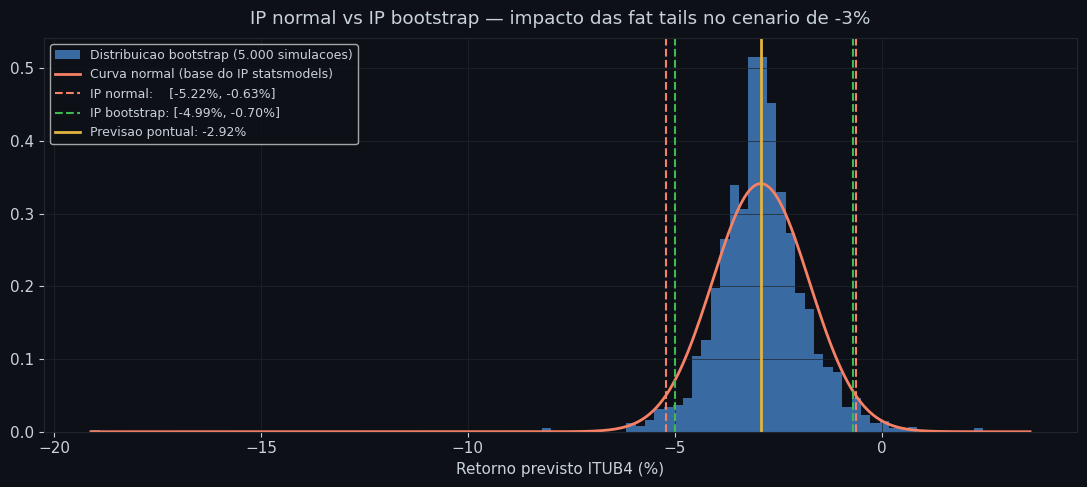

In [55]:
N_BOOT = 5_000
np.random.seed(42)

pred_ponto  = resultado['queda_esperada']
boot_preds  = pred_ponto + np.random.choice(residuos.values, size=N_BOOT, replace=True)

alpha_boot   = 0.05
ip_boot_low  = np.percentile(boot_preds, alpha_boot / 2 * 100)
ip_boot_high = np.percentile(boot_preds, (1 - alpha_boot / 2) * 100)

print(f"IP 95% normal  (statsmodels): [{resultado['ip_low']*100:+.2f}%, {resultado['ip_high']*100:+.2f}%]")
print(f"IP 95% bootstrap (empirico):  [{ip_boot_low*100:+.2f}%, {ip_boot_high*100:+.2f}%]")
print(f"\nDiferenca limite inferior: {(ip_boot_low - resultado['ip_low'])*100:+.2f} pp")
print(f"Diferenca limite superior: {(ip_boot_high - resultado['ip_high'])*100:+.2f} pp")

sigma_normal = (resultado['ip_high'] - resultado['ip_low']) / (2 * 1.96)
x_n = np.linspace(
    min(boot_preds.min(), resultado['ip_low']) * 100,
    max(boot_preds.max(), resultado['ip_high']) * 100, 300
)

fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(boot_preds * 100, bins=100, density=True,
        color=PALETA['azul'], alpha=0.6, label='Distribuicao bootstrap (5.000 simulacoes)')
ax.plot(x_n, stats.norm.pdf(x_n, pred_ponto * 100, sigma_normal * 100),
        color=PALETA['vermelho'], linewidth=2, label='Curva normal (base do IP statsmodels)')

ax.axvline(resultado['ip_low']  * 100, color=PALETA['vermelho'], linewidth=1.5, linestyle='--',
           label=f"IP normal:    [{resultado['ip_low']*100:+.2f}%, {resultado['ip_high']*100:+.2f}%]")
ax.axvline(resultado['ip_high'] * 100, color=PALETA['vermelho'], linewidth=1.5, linestyle='--')

ax.axvline(ip_boot_low  * 100, color=PALETA['verde'], linewidth=1.5, linestyle='--',
           label=f"IP bootstrap: [{ip_boot_low*100:+.2f}%, {ip_boot_high*100:+.2f}%]")
ax.axvline(ip_boot_high * 100, color=PALETA['verde'], linewidth=1.5, linestyle='--')

ax.axvline(pred_ponto * 100, color=PALETA['amarelo'], linewidth=2,
           label=f'Previsao pontual: {pred_ponto*100:+.2f}%')

ax.set_xlabel('Retorno previsto ITUB4 (%)')
ax.set_title('IP normal vs IP bootstrap — impacto das fat tails no cenario de -3%', pad=10)
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

**Leitura do gráfico:** o histograma azul é a distribuição empírica dos 5.000 cenários bootstrap. A curva vermelha é a normal que o statsmodels assume para construir o IP. Se as linhas verdes (IP bootstrap) ficarem mais afastadas da previsão do que as vermelhas (IP normal) — especialmente no limite inferior — significa que a cauda empírica é mais pesada do que a normal pressupõe: o risco real de quedas extremas é maior do que o IP paramétrico indica.

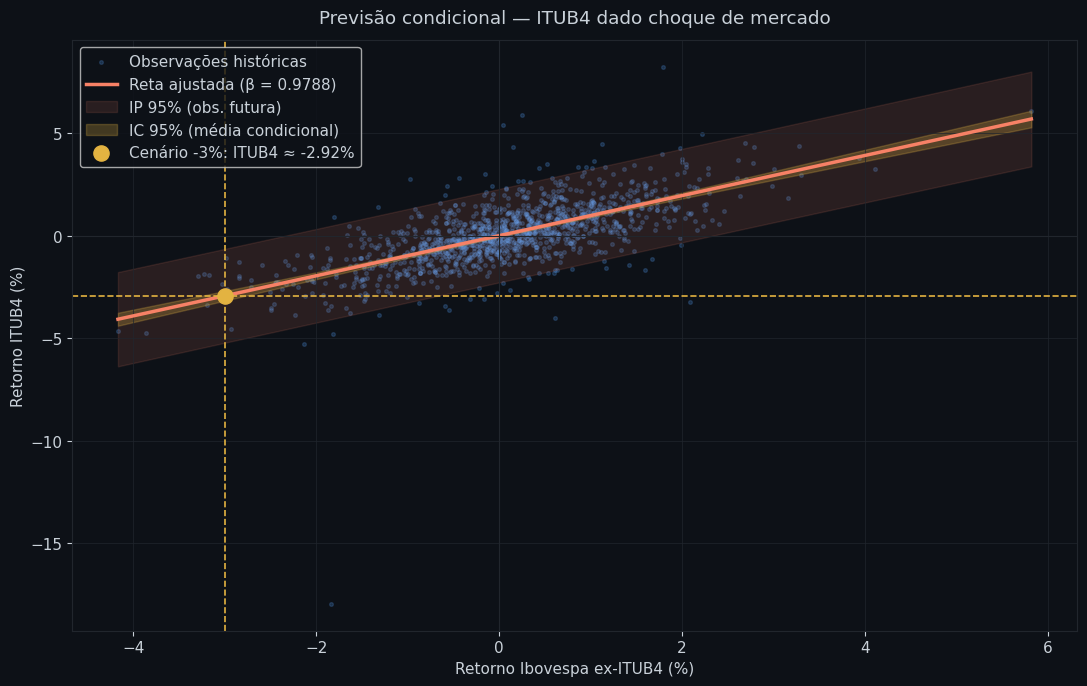

In [56]:
# Visualização final: reta de regressão + cenário
x_range = np.linspace(dados_modelo['ibov_ex'].min(), dados_modelo['ibov_ex'].max(), 300)
X_range = sm.add_constant(pd.Series(x_range, name='ibov_ex'))
pred_range = modelo_b.get_prediction(X_range).summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(dados_modelo['ibov_ex'] * 100,
           dados_modelo['itub4'] * 100,
           color=PALETA['azul'], alpha=0.2, s=7, label='Observações históricas')

ax.plot(x_range * 100, pred_range['mean'] * 100,
        color=PALETA['vermelho'], linewidth=2.5,
        label=f'Reta ajustada (β = {beta_b:.4f})')

ax.fill_between(x_range * 100,
                pred_range['obs_ci_lower'] * 100,
                pred_range['obs_ci_upper'] * 100,
                alpha=0.12, color=PALETA['vermelho'], label='IP 95% (obs. futura)')

ax.fill_between(x_range * 100,
                pred_range['mean_ci_lower'] * 100,
                pred_range['mean_ci_upper'] * 100,
                alpha=0.25, color=PALETA['amarelo'], label='IC 95% (média condicional)')

# Marca o cenário
r = resultado
ax.axvline(CHOQUE * 100, color=PALETA['amarelo'], linewidth=1.2, linestyle='--')
ax.axhline(r['queda_esperada'] * 100, color=PALETA['amarelo'], linewidth=1.2, linestyle='--')
ax.scatter([CHOQUE * 100], [r['queda_esperada'] * 100],
           color=PALETA['amarelo'], s=120, zorder=6,
           label=f"Cenário {CHOQUE*100:.0f}%: ITUB4 ≈ {r['queda_esperada']*100:+.2f}%")

ax.set_xlabel('Retorno Ibovespa ex-ITUB4 (%)')
ax.set_ylabel('Retorno ITUB4 (%)')
ax.set_title('Previsão condicional — ITUB4 dado choque de mercado', pad=12)
ax.legend(loc='upper left')
ax.axhline(0, color=PALETA['grade'], linewidth=0.8)
ax.axvline(0, color=PALETA['grade'], linewidth=0.8)
ax.grid(True)

plt.tight_layout()
plt.show()

**Leitura do gráfico:** cada ponto azul é um dia histórico. A linha vermelha é a reta ajustada — a queda esperada do ITUB4 para cada nível de queda do Ibovespa ex-ITUB4. A faixa amarela escura é o IC 95% da média condicional: onde acreditamos que a média verdadeira está. A faixa vermelha clara é o IP 95%: onde esperamos que uma única observação futura caia. O ponto amarelo marca o cenário: se o Ibovespa ex-ITUB4 cair 3%, o modelo prevê que o ITUB4 caia aproximadamente o valor indicado — com o IP mostrando a amplitude de incerteza para aquele dia específico.